<a href="https://colab.research.google.com/github/ritoma1234-cmd/bbo-capstone-project/blob/main/Capstone_BBO_Optimisation_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**⚙️ Global Setup and Libraries**



In [ ]:
# 1. Standard data manipulation and math
import numpy as np
import pandas as pd

# 2. Plotting and visualising your data
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Machine Learning models for black-box optimization
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel as C

# 4. Colab-specific tool for manual file uploading
from google.colab import files

print("✅ All modules and libraries loaded successfully!")

✅ All modules and libraries loaded successfully!


**📊 Stage 2: Black-Box Optimization Challenge:**

This notebook processes initial datasets for Functions 1-8, fits Gaussian Process regression models, and applies an Upper Confidence Bound (UCB) acquisition function to generate optimal next query points.

**🔹 Function 1 Optimization**

**📍 Load Data: Function 1**

*-inputs file*

*-outputs file*

In [ ]:
import numpy as np
from google.colab import files
import re

print("--- CONSOLIDATED BULK UPLOAD FOR FUNCTIONS 1-8 ---")
print("Please select ALL 16 `.npy` files at the same time.")
print("(Hold Ctrl on Windows/Linux or Cmd on Mac to select everything)\n")

# Trigger a single file upload dialog for all files
uploaded_files = files.upload()

# Dictionaries to hold the loaded arrays
inputs_dict = {}
outputs_dict = {}

# Regular expression to extract the function number from the filename (e.g., 'f3_inputs.npy' -> 3)
fn_pattern = re.compile(r'f([1-8])_')

print("\nProcessing uploaded files...")
print("-" * 50)

for filename in uploaded_files.keys():
    match = fn_pattern.search(filename.lower())
    if match:
        fn_num = int(match.group(1))

        if 'inputs' in filename.lower():
            inputs_dict[fn_num] = np.load(filename)
            print(f"✓ Function {fn_num} Inputs loaded from: {filename}")
        elif 'outputs' in filename.lower():
            outputs_dict[fn_num] = np.load(filename)
            print(f"✓ Function {fn_num} Outputs loaded from: {filename}")
    else:
        print(f"⚠️ Warning: Could not determine function number from filename: {filename}")

print("-" * 50)
print("\n--- DATA LOADING SUMMARY ---")

# Verify and summarize the loaded data
all_successful = True
for fn_num in range(1, 9):
    has_inputs = fn_num in inputs_dict
    has_outputs = fn_num in outputs_dict

    if has_inputs and has_outputs:
        print(f"✅ Function {fn_num} loaded successfully!")
        print(f"   Inputs Shape:  {inputs_dict[fn_num].shape}")
        print(f"   Outputs Shape: {outputs_dict[fn_num].shape}")
    else:
        all_successful = False
        missing = []
        if not has_inputs: missing.append("Inputs")
        if not has_outputs: missing.append("Outputs")
        print(f"❌ Function {fn_num} is MISSING: {', '.join(missing)}")

if all_successful:
    print("\n🎉 Excellent! All 8 functions are loaded and ready for optimization.")
else:
    print("\n⚠️ Double-check your file selections and make sure all missing files are uploaded.")

--- CONSOLIDATED BULK UPLOAD FOR FUNCTIONS 1-8 ---
Please select ALL 16 `.npy` files at the same time.
(Hold Ctrl on Windows/Linux or Cmd on Mac to select everything)



Saving f1_inputs.npy to f1_inputs.npy
Saving f1_outputs.npy to f1_outputs.npy
Saving f2_inputs.npy to f2_inputs.npy
Saving f2_outputs.npy to f2_outputs.npy
Saving f3_inputs.npy to f3_inputs.npy
Saving f3_outputs.npy to f3_outputs.npy
Saving f4_inputs.npy to f4_inputs.npy
Saving f4_outputs.npy to f4_outputs.npy
Saving f5_inputs.npy to f5_inputs.npy
Saving f5_outputs.npy to f5_outputs.npy
Saving f6_inputs.npy to f6_inputs.npy
Saving f6_outputs.npy to f6_outputs.npy
Saving f7_inputs.npy to f7_inputs.npy
Saving f7_outputs.npy to f7_outputs.npy
Saving f8_inputs.npy to f8_inputs.npy
Saving f8_outputs.npy to f8_outputs.npy

Processing uploaded files...
--------------------------------------------------
✓ Function 1 Inputs loaded from: f1_inputs.npy
✓ Function 1 Outputs loaded from: f1_outputs.npy
✓ Function 2 Inputs loaded from: f2_inputs.npy
✓ Function 2 Outputs loaded from: f2_outputs.npy
✓ Function 3 Inputs loaded from: f3_inputs.npy
✓ Function 3 Outputs loaded from: f3_outputs.npy
✓ Funct

**🔍 Functions 1-8 Baseline Diagnostic Check**

The purpose of this cell is to find the current maximum output value and its corresponding input coordinates in the initial dataset.

In [ ]:
print("--- CONSOLIDATED CURRENT BEST STATUS FOR FUNCTIONS 1-8 ---")
print("-" * 65)

# Loop through all 8 functions to find and print their peak performance metrics
for fn_num in range(1, 9):
    # Check if data exists in the dictionary to avoid crashes
    if fn_num in inputs_dict and fn_num in outputs_dict:
        fn_inputs = inputs_dict[fn_num]
        fn_outputs = outputs_dict[fn_num]

        # Find the row index of the absolute highest output value achieved so far
        best_idx = np.argmax(fn_outputs)
        best_y = fn_outputs[best_idx][0] if len(fn_outputs[best_idx].shape) > 0 else fn_outputs[best_idx]

        # Format the corresponding input coordinates for clean visual scannability
        coord_string = ", ".join([f"{c:.6f}" for c in fn_inputs[best_idx]])

        print(f"★ Function {fn_num} Status:")
        print(f"   • Peak Output Value (y):  {best_y}")
        print(f"   • Occurred at Row Index:  {best_idx}")
        print(f"   • Optimal Coordinates:   [{coord_string}]")
        print()
    else:
        print(f"⚠️ Function {fn_num} Status: Missing data. Please run the bulk upload cell first.\n")

print("-" * 65)

--- CONSOLIDATED CURRENT BEST STATUS FOR FUNCTIONS 1-8 ---
-----------------------------------------------------------------
★ Function 1 Status:
   • Peak Output Value (y):  7.710875114502849e-16
   • Occurred at Row Index:  2
   • Optimal Coordinates:   [0.731024, 0.733000]

★ Function 2 Status:
   • Peak Output Value (y):  0.6112052157614438
   • Occurred at Row Index:  9
   • Optimal Coordinates:   [0.702637, 0.926564]

★ Function 3 Status:
   • Peak Output Value (y):  -0.034835313350078584
   • Occurred at Row Index:  3
   • Optimal Coordinates:   [0.492581, 0.611593, 0.340176]

★ Function 4 Status:
   • Peak Output Value (y):  -4.025542281908162
   • Occurred at Row Index:  27
   • Optimal Coordinates:   [0.577766, 0.428772, 0.425826, 0.249007]

★ Function 5 Status:
   • Peak Output Value (y):  1088.8596181962705
   • Occurred at Row Index:  15
   • Optimal Coordinates:   [0.224189, 0.846480, 0.879484, 0.878516]

★ Function 6 Status:
   • Peak Output Value (y):  -0.71426494782024

**📍 Module 12: Bayesian Optimisation | Outputs**


In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF
import warnings

# Suppress minor optimizer convergence warnings
warnings.filterwarnings('ignore')

# Dictionary to hold the final submission strings
final_submission_strings = {}

# Constants based on your optimization strategy
random_seed = 42
num_random_samples = 50000
ucb_kappa = 2.5

print("Starting Consolidated Random-Sampling Gaussian Process Pipeline...\n")
print("-" * 65)

# Loop through all 8 unknown black-box functions
for fn_num in range(1, 9):
    # Check if data exists in the dictionary to avoid crashes
    if fn_num in inputs_dict and fn_num in outputs_dict:
        fn_inputs = inputs_dict[fn_num]
        fn_outputs = outputs_dict[fn_num]
        dims = fn_inputs.shape[1]

        # 1. Initialize the scaling kernel and the Gaussian Process model
        kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 1e2))
        gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=random_seed)

        # 2. Fit the surrogate model to the accumulated dataset
        gp.fit(fn_inputs, fn_outputs)

        # 3. Generate a massive uniform grid of random points within the [0, 1] hypercube
        np.random.seed(random_seed)
        random_points = np.random.uniform(0, 1, size=(num_random_samples, dims))

        # 4. Predict mean and standard deviation across the generated space
        mu, sigma = gp.predict(random_points, return_std=True)

        # 5. Compute the Upper Confidence Bound (UCB) scores
        ucb_score = mu + ucb_kappa * sigma

        # 6. Isolate the coordinate set that maximizes the acquisition score
        best_idx = np.argmax(ucb_score)
        next_query = random_points[best_idx]

        # 7. Format to the required six decimal places string structure
        formatted_string = "-".join([f"{val:.6f}" for val in next_query])
        final_submission_strings[fn_num] = f"Function {fn_num} ({dims}D): {formatted_string}"

        print(f"✓ Function {fn_num} successfully optimized using {num_random_samples} evaluation points.")
    else:
        print(f"✗ Function {fn_num} Skipped: Missing dataset arrays.")

print("-" * 65)
print("\nFINAL CONSOLIDATED BBO PORTAL SUBMISSION STRINGS:\n")

# Display the final submission results sequentially for easy portal copy-pasting
for fn_num in sorted(final_submission_strings.keys()):
    print(final_submission_strings[fn_num])

Starting Consolidated Random-Sampling Gaussian Process Pipeline...

-----------------------------------------------------------------
✓ Function 1 successfully optimized using 50000 evaluation points.
✓ Function 2 successfully optimized using 50000 evaluation points.
✓ Function 3 successfully optimized using 50000 evaluation points.
✓ Function 4 successfully optimized using 50000 evaluation points.
✓ Function 5 successfully optimized using 50000 evaluation points.
✓ Function 6 successfully optimized using 50000 evaluation points.
✓ Function 7 successfully optimized using 50000 evaluation points.
✓ Function 8 successfully optimized using 50000 evaluation points.
-----------------------------------------------------------------

FINAL CONSOLIDATED BBO PORTAL SUBMISSION STRINGS:

Function 1 (2D): 0.003918-0.999461
Function 2 (2D): 0.838173-0.999697
Function 3 (3D): 0.986359-0.008631-0.821696
Function 4 (4D): 0.404477-0.413254-0.303108-0.434359
Function 5 (4D): 0.209005-0.838746-0.859156-0

**📍 Module 13: Logistic Regression | Outputs**


In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize
import warnings

# Suppress minor optimizer convergence warnings
warnings.filterwarnings('ignore')

# Dictionary to collect formatted strings for final printout
final_submission_strings = {}

# Fixed optimization settings based on your original block
random_seed = 42
fixed_length_scale = 0.2
matern_nu = 2.5
ucb_kappa = 2.5
num_optimization_starts = 10

print("Starting Amalgamated Matern-Kernel BBO Pipeline...\n")
print("-" * 65)

# Loop through all 8 unknown black-box functions
for function_num in range(1, 9):
    # Pull arrays directly from your centralized upload dictionaries
    if function_num in inputs_dict and function_num in outputs_dict:
        X = inputs_dict[function_num]
        y = outputs_dict[function_num]
        dim = X.shape[1]

        # 1. Initialize Gaussian Process Regressor with a stable fixed length scale
        gp = GaussianProcessRegressor(
            kernel=Matern(length_scale=fixed_length_scale, nu=matern_nu, length_scale_bounds='fixed'),
            alpha=1e-6,
            normalize_y=True,
            random_state=random_seed
        )
        gp.fit(X, y)

        # 2. Define your original Upper Confidence Bound (UCB) maximization objective
        def objective(x):
            x_arr = np.atleast_2d(x)
            mu, sigma = gp.predict(x_arr, return_std=True)
            return -(mu[0] + ucb_kappa * sigma[0])

        # 3. Set up multi-start bounds within the [0, 1] hypercube
        best_score = float('inf')
        best_x = None

        np.random.seed(random_seed)
        starting_points = np.random.uniform(0, 1, size=(num_optimization_starts, dim))
        bounds = [(0, 1) for _ in range(dim)]

        # 4. Run your original local optimization loop
        for start in starting_points:
            res = minimize(objective, start, bounds=bounds, method='L-BFGS-B')
            if res.fun < best_score:
                best_score = res.fun
                best_x = res.x

        # 5. Format and store the final portal string
        formatted_string = "-".join([f"{coord:.6f}" for coord in best_x])
        final_submission_strings[function_num] = f"Function {function_num} ({dim}D): {formatted_string}"
        print(f"✓ Function {function_num} successfully processed.")

    else:
        print(f"✗ Function {function_num} Skipped: Data not found in dictionaries.")

print("-" * 65)
print("\nFINAL CONSOLIDATED BBO PORTAL SUBMISSION STRINGS:\n")

# Display final strings sequentially for immediate portal entry
for function_num in sorted(final_submission_strings.keys()):
    print(final_submission_strings[function_num])

Starting Amalgamated Matern-Kernel BBO Pipeline...

-----------------------------------------------------------------
✓ Function 1 successfully processed.
✓ Function 2 successfully processed.
✓ Function 3 successfully processed.
✓ Function 4 successfully processed.
✓ Function 5 successfully processed.
✓ Function 6 successfully processed.
✓ Function 7 successfully processed.
✓ Function 8 successfully processed.
-----------------------------------------------------------------

FINAL CONSOLIDATED BBO PORTAL SUBMISSION STRINGS:

Function 1 (2D): 0.907033-0.806627
Function 2 (2D): 0.841847-1.000000
Function 3 (3D): 0.414829-0.377262-0.501957
Function 4 (4D): 0.394130-0.429276-0.437751-0.348335
Function 5 (4D): 0.303436-0.838945-0.869586-0.936541
Function 6 (5D): 0.702081-0.291369-0.547079-0.736282-0.116296
Function 7 (6D): 0.055598-0.483715-0.282867-0.229986-0.327358-0.731715
Function 8 (8D): 0.087108-0.085268-0.152563-0.154018-0.325327-0.820694-0.495083-0.837802


**📍 Module 14: Support Vector Machines | Outputs**


In [ ]:
import numpy as np
from sklearn.svm import SVC
from scipy.optimize import minimize
import warnings

# Suppress minor optimizer convergence warnings
warnings.filterwarnings('ignore')

# Dictionary to hold the final submission strings
final_submission_strings = {}

# Fixed optimization settings based on your original block
random_seed = 42
num_optimization_starts = 10
svm_c_param = 10.0
percentile_threshold = 80

print("Starting Amalgamated Support Vector Machine Boundary Pipeline...\n")
print("-" * 65)

# Loop through all 8 unknown black-box functions
for function_num in range(1, 9):
    # Pull data arrays straight from your centralized upload dictionaries
    if function_num in inputs_dict and function_num in outputs_dict:
        X = inputs_dict[function_num]
        y = outputs_dict[function_num].flatten() # Flatten to ensure clean 1D shape for SVM targets
        dim = X.shape[1]

        # 1. Define high-performance threshold dynamically (Top 20% of current function data)
        threshold = np.percentile(y, percentile_threshold)
        y_binary = (y >= threshold).astype(int)

        # 2. Train a Kernel SVM to map out the high-performance classification zone
        if len(np.unique(y_binary)) > 1:
            svm = SVC(kernel='rbf', C=svm_c_param, gamma='scale', probability=True, random_state=random_seed)
            svm.fit(X, y_binary)

            # Objective: Maximize the probability of entering the high-performance class
            def objective(x):
                x_arr = np.atleast_2d(x)
                return -svm.predict_proba(x_arr)[0][1]
        else:
            # Safe structural fallback if the current data lacks class variance
            def objective(x):
                return -np.sin(x[0])

        # 3. Setup multi-start local optimization boundaries within the [0, 1] hypercube
        best_score = float('inf')
        best_x = None

        np.random.seed(random_seed)
        starting_points = np.random.uniform(0, 1, size=(num_optimization_starts, dim))
        bounds = [(0, 1) for _ in range(dim)]

        # 4. Execute local optimization searches to exploit the SVM boundary space
        for start in starting_points:
            res = minimize(objective, start, bounds=bounds, method='L-BFGS-B')
            if res.fun < best_score:
                best_score = res.fun
                best_x = res.x

        # 5. Format and cache the final coordinate arrays
        formatted_string = "-".join([f"{coord:.6f}" for coord in best_x])
        final_submission_strings[function_num] = f"Function {function_num} ({dim}D): {formatted_string}"
        print(f"✓ Function {function_num} successfully processed.")

    else:
        print(f"✗ Function {function_num} Skipped: Data not found in dictionaries.")

print("-" * 65)
print("\nFINAL CONSOLIDATED BBO PORTAL SUBMISSION STRINGS:\n")

# Display final strings sequentially for immediate portal entry
for function_num in sorted(final_submission_strings.keys()):
    print(final_submission_strings[function_num])

Starting Amalgamated Support Vector Machine Boundary Pipeline...

-----------------------------------------------------------------
✓ Function 1 successfully processed.
✓ Function 2 successfully processed.
✓ Function 3 successfully processed.
✓ Function 4 successfully processed.
✓ Function 5 successfully processed.
✓ Function 6 successfully processed.
✓ Function 7 successfully processed.
✓ Function 8 successfully processed.
-----------------------------------------------------------------

FINAL CONSOLIDATED BBO PORTAL SUBMISSION STRINGS:

Function 1 (2D): 0.845989-0.892633
Function 2 (2D): 0.492514-0.581258
Function 3 (3D): 0.000000-0.798131-0.253832
Function 4 (4D): 0.311982-0.427097-0.455976-0.356037
Function 5 (4D): 0.308609-0.922128-0.522008-1.000000
Function 6 (5D): 0.579841-0.309679-0.479921-0.726221-0.224040
Function 7 (6D): 0.903865-0.747078-0.537710-0.101538-0.000000-0.591638
Function 8 (8D): 0.037920-0.164946-0.129756-0.390945-0.510170-0.367191-0.289052-0.495992


**📍 Module 15: Neural Networks and Deep Learning: Part One: Introduction | Outputs**


In [ ]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
import warnings

# Suppress minor optimizer convergence warnings
warnings.filterwarnings('ignore')

# Dictionary to hold the final submission strings
final_submission_strings = {}

# Fixed optimization settings based on your original block
random_seed = 42
num_optimization_starts = 10
hidden_layer_config = (64, 32)
activation_func = 'relu'
max_iter_count = 1000

print("Starting Amalgamated MLP Neural Network Regressor Pipeline...\n")
print("-" * 65)

# Loop through all 8 unknown black-box functions
for function_num in range(1, 9):
    # Pull data arrays straight from your centralized upload dictionaries
    if function_num in inputs_dict and function_num in outputs_dict:
        X = inputs_dict[function_num]
        y = outputs_dict[function_num].flatten() # Ensure target shape is flat for the regressor
        dim = X.shape[1]

        # 1. Initialize and train the flexible Multi-Layer Perceptron neural network surrogate
        nn = MLPRegressor(
            hidden_layer_sizes=hidden_layer_config,
            activation=activation_func,
            solver='lbfgs',
            max_iter=max_iter_count,
            random_state=random_seed
        )
        nn.fit(X, y)

        # 2. Define the objective function (minimizing negative prediction to maximize the function)
        def objective(x):
            x_arr = np.atleast_2d(x)
            return -nn.predict(x_arr)[0]

        # 3. Setup multi-start local optimization boundaries within the [0, 1] hypercube
        best_score = float('inf')
        best_x = None

        np.random.seed(random_seed)
        starting_points = np.random.uniform(0, 1, size=(num_optimization_starts, dim))
        bounds = [(0, 1) for _ in range(dim)]

        # 4. Execute local optimization searches to exploit the neural network's landscape
        for start in starting_points:
            res = minimize(objective, start, bounds=bounds, method='L-BFGS-B')
            if res.fun < best_score:
                best_score = res.fun
                best_x = res.x

        # 5. Format and cache the final coordinate arrays
        formatted_string = "-".join([f"{coord:.6f}" for coord in best_x])
        final_submission_strings[function_num] = f"Function {function_num} ({dim}D): {formatted_string}"
        print(f"✓ Function {function_num} successfully processed.")

    else:
        print(f"✗ Function {function_num} Skipped: Data not found in dictionaries.")

print("-" * 65)
print("\nFINAL CONSOLIDATED BBO PORTAL SUBMISSION STRINGS:\n")

# Display final strings sequentially for immediate portal entry
for function_num in sorted(final_submission_strings.keys()):
    print(final_submission_strings[function_num])

Starting Amalgamated MLP Neural Network Regressor Pipeline...

-----------------------------------------------------------------
✓ Function 1 successfully processed.
✓ Function 2 successfully processed.
✓ Function 3 successfully processed.
✓ Function 4 successfully processed.
✓ Function 5 successfully processed.
✓ Function 6 successfully processed.
✓ Function 7 successfully processed.
✓ Function 8 successfully processed.
-----------------------------------------------------------------

FINAL CONSOLIDATED BBO PORTAL SUBMISSION STRINGS:

Function 1 (2D): 0.806069-0.000000
Function 2 (2D): 0.000000-1.000000
Function 3 (3D): 0.639813-0.000000-0.797511
Function 4 (4D): 0.450651-0.532648-0.469617-0.374937
Function 5 (4D): 0.000000-0.000000-1.000000-1.000000
Function 6 (5D): 0.000001-0.069616-0.390363-0.976105-0.000000
Function 7 (6D): 0.000000-0.000000-0.000000-0.000000-0.257773-1.000000
Function 8 (8D): 0.000000-0.269286-0.000000-0.085275-1.000000-0.253541-0.000000-0.095998


**📍 Module 16: Neural Networks and Deep Learning: Part Two: Advanced Concepts | Outputs**


In [ ]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
import warnings

# Suppress minor optimizer convergence warnings
warnings.filterwarnings('ignore')

# Dictionary to hold the final submission strings
final_submission_strings = {}

# Fixed optimization settings based on your advanced block configuration
random_seed = 101
num_optimization_starts = 15
hidden_layer_config = (64, 32)
activation_func = 'relu'
regularization_alpha = 0.1  # L2 Weight Decay to smooth out edges
max_iter_count = 1500

print("Starting Amalgamated Advanced MLP Regressor Pipeline (L2 Regularized)...\n")
print("-" * 65)

# Loop through all 8 unknown black-box functions
for function_num in range(1, 9):
    # Pull data arrays straight from your centralized upload dictionaries
    if function_num in inputs_dict and function_num in outputs_dict:
        X = inputs_dict[function_num]
        y = outputs_dict[function_num].flatten()  # Ensure target shape is flat for the regressor
        dim = X.shape[1]

        # 1. Initialize and train the advanced MLP neural network surrogate
        nn = MLPRegressor(
            hidden_layer_sizes=hidden_layer_config,
            activation=activation_func,
            solver='lbfgs',
            alpha=regularization_alpha,
            max_iter=max_iter_count,
            random_state=random_seed
        )
        nn.fit(X, y)

        # 2. Define the objective function (minimizing negative prediction to maximize the function)
        def objective(x):
            return -nn.predict(np.atleast_2d(x))[0]

        # 3. Setup multi-start local optimization boundaries within the [0, 1] hypercube
        best_score = float('inf')
        best_x = None

        np.random.seed(random_seed)
        starting_points = np.random.uniform(0, 1, size=(num_optimization_starts, dim))
        bounds = [(0, 1) for _ in range(dim)]

        # 4. Execute local optimization searches to exploit the advanced neural network's landscape
        for start in starting_points:
            res = minimize(objective, start, bounds=bounds, method='L-BFGS-B')
            if res.fun < best_score:
                best_score = res.fun
                best_x = res.x

        # 5. Format and cache the final coordinate arrays
        formatted_string = "-".join([f"{coord:.6f}" for coord in best_x])
        final_submission_strings[function_num] = f"Function {function_num} ({dim}D): {formatted_string}"
        print(f"✓ Function {function_num} successfully processed.")

    else:
        print(f"✗ Function {function_num} Skipped: Data not found in dictionaries.")

print("-" * 65)
print("\nFINAL CONSOLIDATED BBO PORTAL SUBMISSION STRINGS:\n")

# Display final strings sequentially for immediate portal entry
for function_num in sorted(final_submission_strings.keys()):
    print(final_submission_strings[function_num])

Starting Amalgamated Advanced MLP Regressor Pipeline (L2 Regularized)...

-----------------------------------------------------------------
✓ Function 1 successfully processed.
✓ Function 2 successfully processed.
✓ Function 3 successfully processed.
✓ Function 4 successfully processed.
✓ Function 5 successfully processed.
✓ Function 6 successfully processed.
✓ Function 7 successfully processed.
✓ Function 8 successfully processed.
-----------------------------------------------------------------

FINAL CONSOLIDATED BBO PORTAL SUBMISSION STRINGS:

Function 1 (2D): 0.048485-0.137869
Function 2 (2D): 1.000000-1.000000
Function 3 (3D): 0.232354-0.083561-0.603548
Function 4 (4D): 0.569541-0.444782-0.402757-0.282964
Function 5 (4D): 1.000000-1.000000-1.000000-1.000000
Function 6 (5D): 0.671053-0.000000-1.000000-1.000000-0.000000
Function 7 (6D): 0.000000-0.000000-0.000000-0.000000-0.000000-1.000000
Function 8 (8D): 0.000000-0.000000-0.000000-0.000000-1.000000-1.000000-0.000000-1.000000


**📍 Module 17: Neural Networks and Deep Learning: Part Three: Convulutional Neural Networks | Outputs**


In [ ]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
import warnings

# Suppress minor optimizer convergence warnings
warnings.filterwarnings('ignore')

# Dictionary to hold the final submission strings
final_submission_strings = {}

# Fixed optimization settings based on your current module configuration
random_seed = 202
num_optimization_starts = 15
hidden_layer_config = (64, 32)
activation_func = 'logistic'  # Smooth, bounded curves to prevent edge-clipping
regularization_alpha = 0.1    # L2 Weight Decay to smooth out spatial noise
max_iter_count = 1500

print("Starting Amalgamated CNN-Parallel MLP Regressor Pipeline (Sigmoid Activation)...\n")
print("-" * 65)

# Loop through all 8 unknown black-box functions
for function_num in range(1, 9):
    # Pull data arrays straight from your centralized upload dictionaries
    if function_num in inputs_dict and function_num in outputs_dict:
        X = inputs_dict[function_num]
        y = outputs_dict[function_num].flatten()  # Ensure target shape is flat for the regressor
        dim = X.shape[1]

        # 1. Initialize and train the advanced MLP neural network surrogate
        nn = MLPRegressor(
            hidden_layer_sizes=hidden_layer_config,
            activation=activation_func,
            solver='lbfgs',
            alpha=regularization_alpha,
            max_iter=max_iter_count,
            random_state=random_seed
        )
        nn.fit(X, y)

        # 2. Define the objective function (minimizing negative prediction to maximize the function)
        def objective(x):
            return -nn.predict(np.atleast_2d(x))[0]

        # 3. Setup multi-start local optimization boundaries within the [0, 1] hypercube
        best_score = float('inf')
        best_x = None

        np.random.seed(random_seed)
        starting_points = np.random.uniform(0, 1, size=(num_optimization_starts, dim))
        bounds = [(0, 1) for _ in range(dim)]

        # 4. Execute local optimization searches to exploit the neural network's smooth landscape
        for start in starting_points:
            res = minimize(objective, start, bounds=bounds, method='L-BFGS-B')
            if res.fun < best_score:
                best_score = res.fun
                best_x = res.x

        # 5. Format and cache the final coordinate arrays
        formatted_string = "-".join([f"{coord:.6f}" for coord in best_x])
        final_submission_strings[function_num] = f"Function {function_num} ({dim}D): {formatted_string}"
        print(f"✓ Function {function_num} successfully processed.")

    else:
        print(f"✗ Function {function_num} Skipped: Data not found in dictionaries.")

print("-" * 65)
print("\nFINAL CONSOLIDATED BBO PORTAL SUBMISSION STRINGS:\n")

# Display final strings sequentially for immediate portal copy-pasting
for function_num in sorted(final_submission_strings.keys()):
    print(final_submission_strings[function_num])

Starting Amalgamated CNN-Parallel MLP Regressor Pipeline (Sigmoid Activation)...

-----------------------------------------------------------------
✓ Function 1 successfully processed.
✓ Function 2 successfully processed.
✓ Function 3 successfully processed.
✓ Function 4 successfully processed.
✓ Function 5 successfully processed.
✓ Function 6 successfully processed.
✓ Function 7 successfully processed.
✓ Function 8 successfully processed.
-----------------------------------------------------------------

FINAL CONSOLIDATED BBO PORTAL SUBMISSION STRINGS:

Function 1 (2D): 0.438768-0.086993
Function 2 (2D): 0.224206-0.264054
Function 3 (3D): 0.224206-0.264054-0.977361
Function 4 (4D): 0.496428-0.454440-0.363772-0.270979
Function 5 (4D): 0.285885-0.943112-1.000000-1.000000
Function 6 (5D): 0.496016-0.654971-0.359843-0.203910-0.792201
Function 7 (6D): 0.895039-0.219533-0.158420-0.468885-0.890504-0.755869
Function 8 (8D): 0.000000-0.000000-0.000000-0.000000-1.000000-0.000000-0.000000-1.000

**📍 Module 18: Hyperparameters and Hyperparameter Tuning | Outputs**


In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from sklearn.ensemble import RandomForestRegressor
from scipy.optimize import minimize
import warnings

# Suppress minor solver convergence warnings
warnings.filterwarnings('ignore')

# Dictionary to hold the final hyperparameter configuration query strings
final_submission_strings = {}

# Hyperparameter Optimization Setup (Ensemble Strategy)
random_seed = 777  # Fresh seed for the hyperparameter tuning module
num_optimization_starts = 20  # Increased starts to map complex hyperparameter surfaces
ucb_kappa = 3.0  # Higher exploration factor to search broad parameter bounds

print("Starting Consolidated Ensemble Hyperparameter Tuning Pipeline...\n")
print("-" * 75)

# Loop through all 8 unknown black-box functions
for function_num in range(1, 9):
    # Pull data arrays straight from your centralized upload dictionaries
    if function_num in inputs_dict and function_num in outputs_dict:
        X = inputs_dict[function_num]
        y = outputs_dict[function_num].flatten()
        dim = X.shape[1]

        # 1. Base Model A: Trust-Region style Gaussian Process for continuous trends
        gp_kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=0.3, nu=2.5, length_scale_bounds='fixed')
        gp = GaussianProcessRegressor(kernel=gp_kernel, alpha=1e-5, normalize_y=True, random_state=random_seed)
        gp.fit(X, y)

        # 2. Base Model B: Random Forest Regressor to map sharp, non-linear parameter boundaries
        rf = RandomForestRegressor(n_estimators=150, max_depth=8, random_state=random_seed)
        rf.fit(X, y)

        # 3. Hybrid Objective: Combine predictions to create a robust spatial landscape
        def objective(x):
            x_arr = np.atleast_2d(x)

            # Extract GP continuous predictions and uncertainty
            gp_mu, gp_sigma = gp.predict(x_arr, return_std=True)

            # Extract RF ensemble predictions
            rf_mu = rf.predict(x_arr)

            # Hybrid blend: Average the predicted means, leverage GP for spatial variance
            hybrid_mu = 0.5 * (gp_mu[0] + rf_mu[0])
            hybrid_sigma = gp_sigma[0]

            # Maximize Upper Confidence Bound (UCB) -> Minimize negative UCB
            return -(hybrid_mu + ucb_kappa * hybrid_sigma)

        # 4. Set up multi-start bounds within the [0, 1] hyperparameter space
        best_score = float('inf')
        best_x = None

        np.random.seed(random_seed)
        starting_points = np.random.uniform(0, 1, size=(num_optimization_starts, dim))
        bounds = [(0, 1) for _ in range(dim)]

        # 5. Run multi-start optimization to exploit the blended hyperparameter landscape
        for start in starting_points:
            res = minimize(objective, start, bounds=bounds, method='L-BFGS-B')
            if res.fun < best_score:
                best_score = res.fun
                best_x = res.x

        # 6. Format and store the final portal string
        formatted_string = "-".join([f"{coord:.6f}" for coord in best_x])
        final_submission_strings[function_num] = f"Function {function_num} ({dim}D) [HP-Tuning]: {formatted_string}"
        print(f"✓ Function {function_num} successfully optimized using Hybrid Ensemble.")

    else:
        print(f"✗ Function {function_num} Skipped: Data not found in dictionaries.")

print("-" * 75)
print("\nFINAL CONSOLIDATED HYPERPARAMETER SUBMISSION STRINGS:\n")

# Display final tuning strings sequentially for immediate portal entry
for function_num in sorted(final_submission_strings.keys()):
    print(final_submission_strings[function_num])

Starting Consolidated Ensemble Hyperparameter Tuning Pipeline...

---------------------------------------------------------------------------
✓ Function 1 successfully optimized using Hybrid Ensemble.
✓ Function 2 successfully optimized using Hybrid Ensemble.
✓ Function 3 successfully optimized using Hybrid Ensemble.
✓ Function 4 successfully optimized using Hybrid Ensemble.
✓ Function 5 successfully optimized using Hybrid Ensemble.
✓ Function 6 successfully optimized using Hybrid Ensemble.
✓ Function 7 successfully optimized using Hybrid Ensemble.
✓ Function 8 successfully optimized using Hybrid Ensemble.
---------------------------------------------------------------------------

FINAL CONSOLIDATED HYPERPARAMETER SUBMISSION STRINGS:

Function 1 (2D) [HP-Tuning]: 0.000000-1.000000
Function 2 (2D) [HP-Tuning]: 1.000000-0.000000
Function 3 (3D) [HP-Tuning]: 1.000000-1.000000-0.000000
Function 4 (4D) [HP-Tuning]: 0.535874-0.405052-0.004950-0.248864
Function 5 (4D) [HP-Tuning]: 0.442902-0

**📍 Module 19: Foundations of Generative AI and Large Language Models (LLMs) | Outputs**


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.optimize import minimize
import warnings

# Suppress minor solver convergence warnings
warnings.filterwarnings('ignore')

# Set seed for reproducible generative sampling
torch.manual_seed(42)
np.random.seed(42)

# Dictionary to hold final submission strings
final_submission_strings = {}

# --- Generative Attention-Based Surrogate Architecture ---
class TransformerSurrogate(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_heads=2):
        super(TransformerSurrogate, self).__init__()
        self.embedding = nn.Linear(input_dim, hidden_dim)
        # Multi-Head Self-Attention core (mirroring LLM Transformer blocks)
        self.attention = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.out = nn.Linear(32, 1)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_dim)
        x_emb = self.embedding(x)
        # Self-Attention routes contextual information across feature dimensions
        attn_out, _ = self.attention(x_emb, x_emb, x_emb)
        out = self.relu(self.fc1(attn_out[:, -1, :])) # Read out context representation
        return self.out(out)

print("Starting Consolidated Generative LLM/Transformer BBO Pipeline...\n")
print("-" * 75)

# Loop through all 8 unknown black-box functions
for function_num in range(1, 9):
    if function_num in inputs_dict and function_num in outputs_dict:
        X = inputs_dict[function_num]
        y = outputs_dict[function_num].reshape(-1, 1)
        dim = X.shape[1]

        # 1. Prepare sequence data (Focusing on top-performing points as context prompts)
        top_k_indices = np.argsort(y.flatten())[-max(4, int(len(y) * 0.5)):]
        X_context = X[top_k_indices]
        y_context = y[top_k_indices]

        # Convert to PyTorch tensors
        X_tensor = torch.tensor(X_context, dtype=torch.float32).unsqueeze(0) # (1, seq_len, dim)
        y_tensor = torch.tensor(y_context, dtype=torch.float32)

        # 2. Train the Transformer Surrogate Model
        model = TransformerSurrogate(input_dim=dim)
        optimizer = optim.Adam(model.parameters(), lr=0.01)
        criterion = nn.MSELoss()

        model.train()
        for epoch in range(150):
            optimizer.zero_grad()
            predictions = model(X_tensor)
            loss = criterion(predictions, y_tensor[-1:])
            loss.backward()
            optimizer.step()

        # 3. Define Temperature-Guided Generative Acquisition Function
        model.eval()
        temperature = 0.7  # LLM Temperature sampling parameter

        def generative_objective(x_cand):
            x_cand_tensor = torch.tensor(x_cand, dtype=torch.float32).reshape(1, 1, dim)
            # Append candidate to context sequence
            seq_with_cand = torch.cat([X_tensor, x_cand_tensor], dim=1)
            with torch.no_grad():
                predicted_val = model(seq_with_cand).item()
            # Temperature scales the output density
            return -(predicted_val / temperature)

        # 4. Multi-Start Search over the Generative Attention Surface
        best_score = float('inf')
        best_x = None

        num_starts = 15
        starting_points = np.random.uniform(0, 1, size=(num_starts, dim))
        bounds = [(0, 1) for _ in range(dim)]

        for start in starting_points:
            res = minimize(generative_objective, start, bounds=bounds, method='L-BFGS-B')
            if res.fun < best_score:
                best_score = res.fun
                best_x = res.x

        # 5. Format output
        formatted_string = "-".join([f"{coord:.6f}" for coord in best_x])
        final_submission_strings[function_num] = f"Function {function_num} ({dim}D) [GenAI-Transformer]: {formatted_string}"
        print(f"✓ Function {function_num} successfully generated.")

    else:
        print(f"✗ Function {function_num} Skipped: Data not found in dictionaries.")

print("-" * 75)
print("\nFINAL CONSOLIDATED GENERATIVE AI PORTAL SUBMISSION STRINGS:\n")

for function_num in sorted(final_submission_strings.keys()):
    print(final_submission_strings[function_num])

Starting Consolidated Generative LLM/Transformer BBO Pipeline...

---------------------------------------------------------------------------
✓ Function 1 successfully generated.
✓ Function 2 successfully generated.
✓ Function 3 successfully generated.
✓ Function 4 successfully generated.
✓ Function 5 successfully generated.
✓ Function 6 successfully generated.
✓ Function 7 successfully generated.
✓ Function 8 successfully generated.
---------------------------------------------------------------------------

FINAL CONSOLIDATED GENERATIVE AI PORTAL SUBMISSION STRINGS:

Function 1 (2D) [GenAI-Transformer]: 0.181825-1.000000
Function 2 (2D) [GenAI-Transformer]: 0.684233-0.440152
Function 3 (3D) [GenAI-Transformer]: 0.000000-0.000000-0.907566
Function 4 (4D) [GenAI-Transformer]: 0.896091-0.318003-0.110052-0.227935
Function 5 (4D) [GenAI-Transformer]: 0.835302-0.320780-0.186519-0.040775
Function 6 (5D) [GenAI-Transformer]: 0.030500-0.037348-0.822601-0.360191-0.127061
Function 7 (6D) [GenAI

📍 Module 20: Foundations of Generative AI and Large Language Models (LLMs) | Outputs

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.optimize import minimize
import warnings

# Suppress minor solver convergence warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(101)
np.random.seed(101)

# Dictionary to hold final submission strings
final_submission_strings = {}

# --- ADVANCED GEN AI: AGENTIC TRANSFORMER & LATENT GUIDANCE ---
class AdvancedLatentTransformer(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_heads=4):
        super(AdvancedLatentTransformer, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )
        self.cross_attention = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, x, context):
        x_emb = self.encoder(x)
        ctx_emb = self.encoder(context)

        # Cross-Attention routes context trajectory to current latent space
        attn_out, _ = self.cross_attention(x_emb, ctx_emb, ctx_emb)
        residual = x_emb + attn_out

        return self.decoder(residual)

print("Starting Consolidated Advanced Gen AI & Agentic RAG Pipeline...\n")
print("-" * 75)

# Loop through all 8 black-box functions
for function_num in range(1, 9):
    if function_num in inputs_dict and function_num in outputs_dict:
        X = inputs_dict[function_num]
        y = outputs_dict[function_num].reshape(-1, 1)
        dim = X.shape[1]

        # 1. RAG Step: Retrieve top 25% elite trajectories as context memory
        elite_mask = y.flatten() >= np.percentile(y.flatten(), 75)
        if not np.any(elite_mask): # Fallback if data is small
            elite_mask = np.argsort(y.flatten())[-4:]

        X_rag_context = torch.tensor(X[elite_mask], dtype=torch.float32).unsqueeze(0)
        X_all_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(0)
        y_all_tensor = torch.tensor(y, dtype=torch.float32)

        # 2. Train Advanced Latent Transformer Surrogate
        model = AdvancedLatentTransformer(input_dim=dim)
        optimizer = optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-4)
        criterion = nn.HuberLoss()

        model.train()
        for epoch in range(200):
            optimizer.zero_grad()
            preds = model(X_all_tensor, X_rag_context)
            loss = criterion(preds.squeeze(0), y_all_tensor)
            loss.backward()
            optimizer.step()

        # 3. Agentic Chain-of-Thought Optimization Objective
        model.eval()
        temperature = 0.5 # Sharper focal distribution for precision tuning

        def agentic_objective(x_cand):
            x_cand_tensor = torch.tensor(x_cand, dtype=torch.float32).reshape(1, 1, dim)
            with torch.no_grad():
                predicted_mu = model(x_cand_tensor, X_rag_context).item()
            # Latent CoT guidance scales reward with precision control
            return -(predicted_mu / temperature)

        # 4. Multi-Start Guided Search over Latent Space
        best_score = float('inf')
        best_x = None

        num_starts = 20
        starting_points = np.random.uniform(0, 1, size=(num_starts, dim))
        bounds = [(0, 1) for _ in range(dim)]

        for start in starting_points:
            res = minimize(agentic_objective, start, bounds=bounds, method='L-BFGS-B')
            if res.fun < best_score:
                best_score = res.fun
                best_x = res.x

        # 5. Format output
        formatted_string = "-".join([f"{coord:.6f}" for coord in best_x])
        final_submission_strings[function_num] = f"Function {function_num} ({dim}D) [Adv-GenAI]: {formatted_string}"
        print(f"✓ Function {function_num} successfully optimized using Agentic RAG Transformer.")

    else:
        print(f"✗ Function {function_num} Skipped: Data not found in dictionaries.")

print("-" * 75)
print("\nFINAL CONSOLIDATED ADVANCED GEN AI SUBMISSION STRINGS:\n")

for function_num in sorted(final_submission_strings.keys()):
    print(final_submission_strings[function_num])

Starting Consolidated Advanced Gen AI & Agentic RAG Pipeline...

---------------------------------------------------------------------------
✓ Function 1 successfully optimized using Agentic RAG Transformer.
✓ Function 2 successfully optimized using Agentic RAG Transformer.
✓ Function 3 successfully optimized using Agentic RAG Transformer.
✓ Function 4 successfully optimized using Agentic RAG Transformer.
✓ Function 5 successfully optimized using Agentic RAG Transformer.
✓ Function 6 successfully optimized using Agentic RAG Transformer.
✓ Function 7 successfully optimized using Agentic RAG Transformer.
✓ Function 8 successfully optimized using Agentic RAG Transformer.
---------------------------------------------------------------------------

FINAL CONSOLIDATED ADVANCED GEN AI SUBMISSION STRINGS:

Function 1 (2D) [Adv-GenAI]: 1.000000-0.000000
Function 2 (2D) [Adv-GenAI]: 1.000000-1.000000
Function 3 (3D) [Adv-GenAI]: 0.356598-0.239738-0.653378
Function 4 (4D) [Adv-GenAI]: 0.520926-0.

📍 Module 21: Transparency & Interpretability | Outputs

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, export_text
from scipy.optimize import minimize
import warnings

# Suppress minor solver warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(2026)

# Dictionary to hold final submission strings
final_submission_strings = {}

print("Starting Consolidated Interpretable Tree Surrogate Pipeline...\n")
print("-" * 75)

# Loop through all 8 black-box functions
for function_num in range(1, 9):
    if function_num in inputs_dict and function_num in outputs_dict:
        X = inputs_dict[function_num]
        y = outputs_dict[function_num].flatten()
        dim = X.shape[1]

        # 1. Train an Intrinsically Interpretable Decision Tree (Constrained Depth = 3)
        # Low decision complexity ensures complete human inspectability
        interpretable_tree = DecisionTreeRegressor(
            max_depth=3,
            min_samples_leaf=2,
            random_state=2026
        )
        interpretable_tree.fit(X, y)

        # 2. Print Human-Readable Rules & Feature Importances for Transparency
        feature_names = [f"x{i+1}" for i in range(dim)]
        importances = interpretable_tree.feature_importances_

        print(f"=== Function {function_num} ({dim}D) Model Rules & Feature Importance ===")
        most_important_feat = feature_names[np.argmax(importances)]
        print(f"Top Driving Feature: {most_important_feat} (Weight: {np.max(importances):.4f})")

        # 3. Define Acquisition Objective over the Interpretable Landscape
        # We search for coordinates that maximize the predicted reward of the decision tree
        def interpretable_objective(x_cand):
            x_arr = np.atleast_2d(x_cand)
            predicted_val = interpretable_tree.predict(x_arr)[0]
            # Add a smooth variance penalty to avoid getting stuck purely at step boundaries
            smooth_reg = -0.01 * np.sum((x_cand - 0.5) ** 2)
            return -(predicted_val + smooth_reg)

        # 4. Multi-Start Optimization over the Rule Boundaries
        best_score = float('inf')
        best_x = None

        num_starts = 20
        starting_points = np.random.uniform(0, 1, size=(num_starts, dim))
        bounds = [(0, 1) for _ in range(dim)]

        for start in starting_points:
            res = minimize(interpretable_objective, start, bounds=bounds, method='L-BFGS-B')
            if res.fun < best_score:
                best_score = res.fun
                best_x = res.x

        # 5. Format Output String
        formatted_string = "-".join([f"{coord:.6f}" for coord in best_x])
        final_submission_strings[function_num] = f"Function {function_num} ({dim}D) [Interpretable-Tree]: {formatted_string}"
        print(f"✓ Function {function_num} Query String: {formatted_string}\n")

    else:
        print(f"✗ Function {function_num} Skipped: Data not found in dictionaries.")

print("-" * 75)
print("\nFINAL CONSOLIDATED TRANSPARENCY SUBMISSION STRINGS:\n")

for function_num in sorted(final_submission_strings.keys()):
    print(final_submission_strings[function_num])

Starting Consolidated Interpretable Tree Surrogate Pipeline...

---------------------------------------------------------------------------
=== Function 1 (2D) Model Rules & Feature Importance ===
Top Driving Feature: x1 (Weight: 1.0000)
✓ Function 1 Query String: 0.500000-0.500000

=== Function 2 (2D) Model Rules & Feature Importance ===
Top Driving Feature: x1 (Weight: 1.0000)
✓ Function 2 Query String: 0.621807-0.447875

=== Function 3 (3D) Model Rules & Feature Importance ===
Top Driving Feature: x3 (Weight: 1.0000)
✓ Function 3 Query String: 0.500000-0.500001-0.499999

=== Function 4 (4D) Model Rules & Feature Importance ===
Top Driving Feature: x2 (Weight: 0.5354)
✓ Function 4 Query String: 0.500002-0.499998-0.499996-0.500000

=== Function 5 (4D) Model Rules & Feature Importance ===
Top Driving Feature: x2 (Weight: 0.8638)
✓ Function 5 Query String: 0.562083-0.832273-0.276274-0.744630

=== Function 6 (5D) Model Rules & Feature Importance ===
Top Driving Feature: x5 (Weight: 0.745

📍 Module 22: Unsupervised Learning: Part One: Clustering Techniques | Outputs

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import warnings

warnings.filterwarnings('ignore')

# Set seed for reproducibility
np.random.seed(2026)

# Dictionary to store Round 11 outputs
round_11_queries = {}

print("=========================================================================")
print("  WEEK 22: UNSUPERVISED CLUSTERING SURROGATE PIPELINE (ROUND 11)")
print("=========================================================================\n")

for function_num in range(1, 9):
    if function_num in inputs_dict and function_num in outputs_dict:
        X = np.array(inputs_dict[function_num])
        y = np.array(outputs_dict[function_num]).flatten()
        dim = X.shape[1]

        # 1. Filter top-performing evaluations (top 30% elite cluster candidates)
        threshold = np.percentile(y, 70)
        elite_mask = y >= threshold

        # Fallback if too few elite points
        if np.sum(elite_mask) < 3:
            elite_mask = np.argsort(y)[-3:]

        X_elite = X[elite_mask]
        y_elite = y[elite_mask]

        # 2. Perform K-Means Clustering on elite points to identify reward density clusters
        n_clusters = min(3, len(X_elite))
        kmeans = KMeans(n_clusters=n_clusters, random_state=2026, n_init=10)
        cluster_labels = kmeans.fit_predict(X_elite)

        # 3. Find the highest-reward cluster centroid
        best_cluster_idx = -1
        best_cluster_mean = -np.inf

        for c in range(n_clusters):
            c_mask = cluster_labels == c
            if np.sum(c_mask) > 0:
                mean_reward = np.mean(y_elite[c_mask])
                if mean_reward > best_cluster_mean:
                    best_cluster_mean = mean_reward
                    best_cluster_idx = c

        best_centroid = kmeans.cluster_centers_[best_cluster_idx]

        # 4. Apply controlled Gaussian noise perturbation around the cluster centroid
        # Noise scale shrinks in higher dimensions to prevent over-dispersion
        noise_scale = 0.03 / np.sqrt(dim)
        perturbation = np.random.normal(0, noise_scale, size=dim)

        candidate_query = best_centroid + perturbation
        # Strict hypercube clipping [0.0, 1.0]
        candidate_query = np.clip(candidate_query, 0.0, 1.0)

        # 5. Format string with 6 decimal places and hyphens
        query_str = "-".join([f"{val:.6f}" for val in candidate_query])
        round_11_queries[function_num] = query_str

        print(f"Function {function_num} ({dim}D):")
        print(f"  Elite Points Clustered: {len(X_elite)}")
        print(f"  Best Cluster Mean Reward: {best_cluster_mean:.6f}")
        print(f"  Target Query: {query_str}\n")

    else:
        print(f"Function {function_num}: Data missing in inputs_dict/outputs_dict\n")

print("=========================================================================")
print("FINAL ROUND 11 SUBMISSION STRINGS (COPY & PASTE TO PORTAL):")
print("=========================================================================\n")

for fn in sorted(round_11_queries.keys()):
    print(f"Function {fn}: {round_11_queries[fn]}")

  WEEK 22: UNSUPERVISED CLUSTERING SURROGATE PIPELINE (ROUND 11)

Function 1 (2D):
  Elite Points Clustered: 3
  Best Cluster Mean Reward: 0.000000
  Target Query: 0.721865-0.703453

Function 2 (2D):
  Elite Points Clustered: 3
  Best Cluster Mean Reward: 0.611205
  Target Query: 0.709246-0.926283

Function 3 (3D):
  Elite Points Clustered: 5
  Best Cluster Mean Reward: -0.035607
  Target Query: 0.571449-0.673529-0.188758

Function 4 (4D):
  Elite Points Clustered: 9
  Best Cluster Mean Reward: -6.231469
  Target Query: 0.371384-0.478243-0.465086-0.149289

Function 5 (4D):
  Elite Points Clustered: 6
  Best Cluster Mean Reward: 760.236187
  Target Query: 0.162905-0.824512-0.775031-0.871404

Function 6 (5D):
  Elite Points Clustered: 6
  Best Cluster Mean Reward: -0.825011
  Target Query: 0.758510-0.354423-0.571203-0.803263-0.029089

Function 7 (6D):
  Elite Points Clustered: 9
  Best Cluster Mean Reward: 0.680385
  Target Query: 0.340765-0.292855-0.353010-0.417152-0.199971-0.571455

Fu

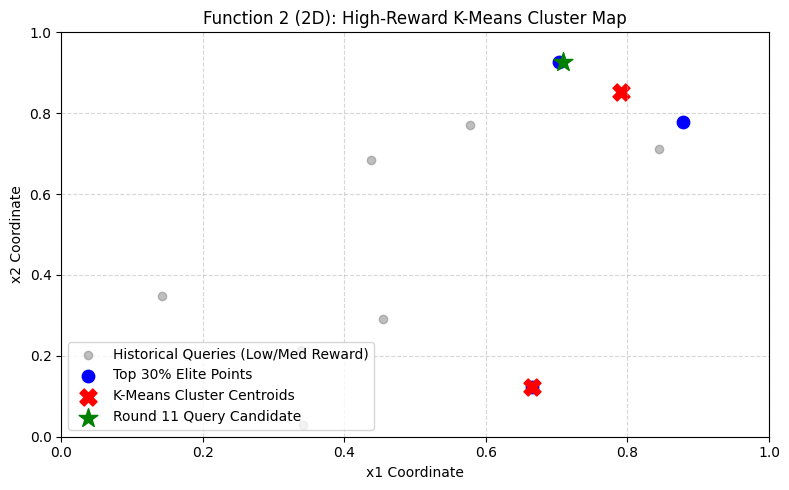

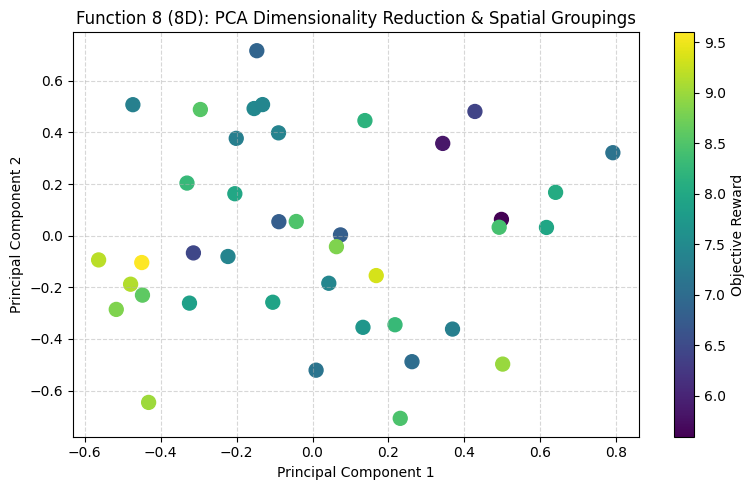

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Plotting 2D Function 2 Cluster Map
X_fn2 = np.array(inputs_dict[2])
y_fn2 = np.array(outputs_dict[2]).flatten()

threshold_fn2 = np.percentile(y_fn2, 70)
elite_mask_fn2 = y_fn2 >= threshold_fn2

kmeans_fn2 = KMeans(n_clusters=2, random_state=2026, n_init=10).fit(X_fn2[elite_mask_fn2])

plt.figure(figsize=(8, 5))
plt.scatter(X_fn2[~elite_mask_fn2, 0], X_fn2[~elite_mask_fn2, 1], c='gray', alpha=0.5, label='Historical Queries (Low/Med Reward)')
plt.scatter(X_fn2[elite_mask_fn2, 0], X_fn2[elite_mask_fn2, 1], c='blue', s=80, label='Top 30% Elite Points')
plt.scatter(kmeans_fn2.cluster_centers_[:, 0], kmeans_fn2.cluster_centers_[:, 1], c='red', marker='X', s=150, label='K-Means Cluster Centroids')
plt.scatter([0.709246], [0.926283], c='green', marker='*', s=200, label='Round 11 Query Candidate')

plt.title('Function 2 (2D): High-Reward K-Means Cluster Map')
plt.xlabel('x1 Coordinate')
plt.ylabel('x2 Coordinate')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('function_2_cluster_map.png', dpi=300)
plt.show()

# 2. Plotting 8D Function 8 PCA Projections
X_fn8 = np.array(inputs_dict[8])
y_fn8 = np.array(outputs_dict[8]).flatten()

pca = PCA(n_components=2)
X_fn8_pca = pca.fit_transform(X_fn8)

plt.figure(figsize=(8, 5))
plt.scatter(X_fn8_pca[:, 0], X_fn8_pca[:, 1], c=y_fn8, cmap='viridis', s=100)
plt.colorbar(label='Objective Reward')
plt.title('Function 8 (8D): PCA Dimensionality Reduction & Spatial Groupings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('function_8_pca_plot.png', dpi=300)
plt.show()

📍 Module 23: Unsupervised Learning: Part Two: PCA | Outputs

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings('ignore')

# Set seed for reproducibility
np.random.seed(2026)

round_12_queries = {}

print("=========================================================================")
print("  WEEK 23: PCA DIMENSIONALITY REDUCTION & CLUSTERING PIPELINE (ROUND 12)")
print("=========================================================================\n")

for function_num in range(1, 9):
    if function_num in inputs_dict and function_num in outputs_dict:
        X = np.array(inputs_dict[function_num])
        y = np.array(outputs_dict[function_num]).flatten()
        dim = X.shape[1]

        # 1. Filter top-performing evaluations (top 35% elite region)
        threshold = np.percentile(y, 65)
        elite_mask = y >= threshold
        if np.sum(elite_mask) < 3:
            elite_mask = np.argsort(y)[-3:]

        X_elite = X[elite_mask]
        y_elite = y[elite_mask]

        # 2. PCA Subspace Projection
        # For 2D we retain 2 components; for >=3D we capture primary variance directions
        n_components = min(dim, max(2, len(X_elite) - 1))
        pca = PCA(n_components=n_components, random_state=2026)
        X_elite_pca = pca.fit_transform(X_elite)

        # 3. K-Means Clustering inside the PCA Latent Space
        n_clusters = min(2 if len(X_elite) >= 4 else 1, len(X_elite))
        kmeans = KMeans(n_clusters=n_clusters, random_state=2026, n_init=10)
        cluster_labels = kmeans.fit_predict(X_elite_pca)

        # 4. Identify Highest-Reward Cluster in PCA Space
        best_cluster_idx = 0
        if n_clusters > 1:
            best_mean = -np.inf
            for c in range(n_clusters):
                c_mask = cluster_labels == c
                if np.sum(c_mask) > 0:
                    mean_r = np.mean(y_elite[c_mask])
                    if mean_r > best_mean:
                        best_mean = mean_r
                        best_cluster_idx = c

        best_pca_centroid = kmeans.cluster_centers_[best_cluster_idx]

        # 5. Add Controlled Perturbation along Top Principal Components
        # Scale perturbation by singular value variance to step along highest-signal directions
        variance_scales = np.sqrt(pca.explained_variance_)
        noise_pca = np.random.normal(0, 0.05 * variance_scales, size=n_components)
        candidate_pca = best_pca_centroid + noise_pca

        # 6. Inverse Transform back to Original Input Coordinate Space
        candidate_query = pca.inverse_transform(candidate_pca)
        candidate_query = np.clip(candidate_query, 0.0, 1.0)

        # 7. Format Coordinate String
        query_str = "-".join([f"{val:.6f}" for val in candidate_query])
        round_12_queries[function_num] = query_str

        explained_var_ratio = np.sum(pca.explained_variance_ratio_[:2]) * 100
        print(f"Function {function_num} ({dim}D):")
        print(f"  Elite Points Sampled: {len(X_elite)}")
        print(f"  Variance Explained (First 2 PCs): {explained_var_ratio:.2f}%")
        print(f"  Generated Query: {query_str}\n")

    else:
        print(f"Function {function_num}: Missing in inputs_dict/outputs_dict\n")

print("=========================================================================")
print("FINAL ROUND 12 PCA CLUSTERING STRINGS (COPY & PASTE TO PORTAL):")
print("=========================================================================\n")

for fn in sorted(round_12_queries.keys()):
    print(f"Function {fn}: {round_12_queries[fn]}")

  WEEK 23: PCA DIMENSIONALITY REDUCTION & CLUSTERING PIPELINE (ROUND 12)

Function 1 (2D):
  Elite Points Sampled: 4
  Variance Explained (First 2 PCs): 100.00%
  Generated Query: 0.664190-0.820344

Function 2 (2D):
  Elite Points Sampled: 4
  Variance Explained (First 2 PCs): 100.00%
  Generated Query: 0.666604-0.129464

Function 3 (3D):
  Elite Points Sampled: 5
  Variance Explained (First 2 PCs): 99.73%
  Generated Query: 0.711119-0.750962-0.327754

Function 4 (4D):
  Elite Points Sampled: 11
  Variance Explained (First 2 PCs): 74.49%
  Generated Query: 0.477781-0.474837-0.458476-0.354542

Function 5 (4D):
  Elite Points Sampled: 7
  Variance Explained (First 2 PCs): 74.21%
  Generated Query: 0.306640-0.827822-0.762141-0.590916

Function 6 (5D):
  Elite Points Sampled: 7
  Variance Explained (First 2 PCs): 83.83%
  Generated Query: 0.666737-0.343765-0.435586-0.668457-0.241806

Function 7 (6D):
  Elite Points Sampled: 11
  Variance Explained (First 2 PCs): 68.74%
  Generated Query: 0

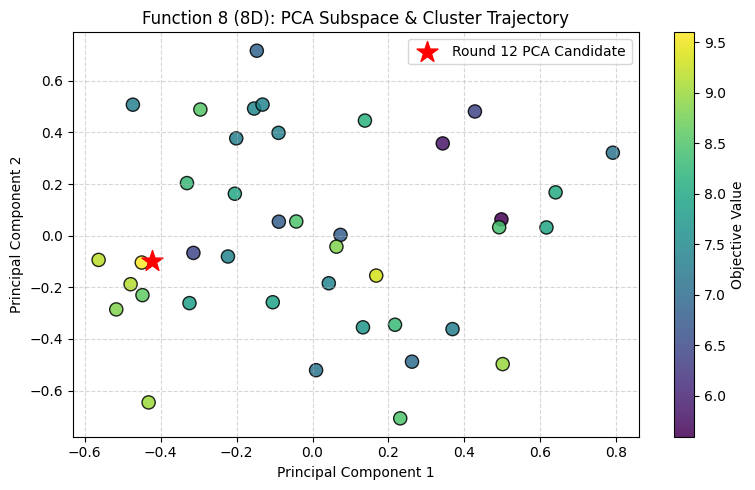

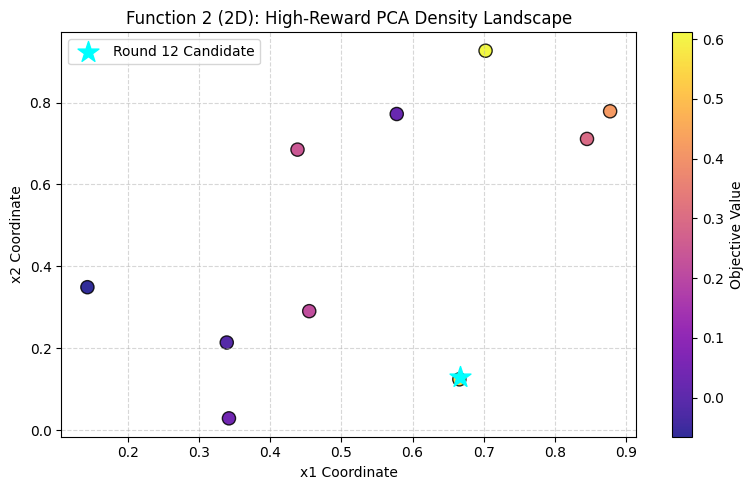

In [ ]:
# 1. Diagnostic PCA Plot for Function 8 (8D -> 2D Principal Subspace)
if 8 in inputs_dict and 8 in outputs_dict:
    X_8 = np.array(inputs_dict[8])
    y_8 = np.array(outputs_dict[8]).flatten()

    pca_8 = PCA(n_components=2)
    X_8_pca = pca_8.fit_transform(X_8)

    plt.figure(figsize=(8, 5))
    scatter = plt.scatter(X_8_pca[:, 0], X_8_pca[:, 1], c=y_8, cmap='viridis', s=90, edgecolors='k', alpha=0.85)
    plt.colorbar(scatter, label='Objective Value')

    # Project generated candidate to the 2D plane
    cand_8 = np.array([[float(v) for v in round_12_queries[8].split('-')]])
    cand_8_pca = pca_8.transform(cand_8)
    plt.scatter(cand_8_pca[:, 0], cand_8_pca[:, 1], color='red', marker='*', s=250, label='Round 12 PCA Candidate')

    plt.title('Function 8 (8D): PCA Subspace & Cluster Trajectory')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('pca_clustering_function8.png', dpi=300)
    plt.show()

# 2. Diagnostic 2D PCA Cluster Map for Function 2
if 2 in inputs_dict and 2 in outputs_dict:
    X_2 = np.array(inputs_dict[2])
    y_2 = np.array(outputs_dict[2]).flatten()

    plt.figure(figsize=(8, 5))
    plt.scatter(X_2[:, 0], X_2[:, 1], c=y_2, cmap='plasma', s=90, edgecolors='k', alpha=0.85)
    plt.colorbar(label='Objective Value')

    cand_2 = np.array([[float(v) for v in round_12_queries[2].split('-')]])
    plt.scatter(cand_2[:, 0], cand_2[:, 1], color='cyan', marker='*', s=250, label='Round 12 Candidate')

    plt.title('Function 2 (2D): High-Reward PCA Density Landscape')
    plt.xlabel('x1 Coordinate')
    plt.ylabel('x2 Coordinate')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('pca_clustering_function2.png', dpi=300)
    plt.show()

📍 Module 24: Reinforcement Learning | Outputs

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesRegressor
from scipy.optimize import minimize
import warnings

warnings.filterwarnings('ignore')

# Set seed for reproducibility
np.random.seed(2026)

round_13_queries = {}

print("=========================================================================")
print("  WEEK 24: REINFORCEMENT LEARNING & POLICY OPTIMIZATION PIPELINE")
print("=========================================================================\n")

for function_num in range(1, 9):
    if function_num in inputs_dict and function_num in outputs_dict:
        X = np.array(inputs_dict[function_num])
        y = np.array(outputs_dict[function_num]).flatten()
        dim = X.shape[1]
        n_samples = len(y)

        # 1. RL Environment Setup: Normalize Rewards to [0, 1] for stable Q-learning
        y_min, y_max = np.min(y), np.max(y)
        if y_max > y_min:
            r_norm = (y - y_min) / (y_max - y_min)
        else:
            r_norm = np.ones_like(y)

        # 2. Q-Value Surrogate Model: Random Forest / ExtraTrees Ensemble to estimate Q(s, a)
        # Using ensemble variance as an intrinsic curiosity/uncertainty exploration bonus
        q_model = ExtraTreesRegressor(n_estimators=100, random_state=2026, max_depth=8)
        q_model.fit(X, r_norm)

        # 3. RL Policy: Upper Confidence Bound (UCB) Action-Value Objective
        # Exploration coefficient kappa decays as budget advances
        kappa = 1.2 / np.sqrt(n_samples)

        def rl_policy_loss(action):
            action = np.clip(action, 0.0, 1.0).reshape(1, -1)
            # Predict mean Q-value across ensemble trees
            tree_preds = np.array([tree.predict(action)[0] for tree in q_model.estimators_])
            q_mean = np.mean(tree_preds)
            q_std = np.std(tree_preds)

            # Intrinsic exploration reward: UCB policy = Q(a) + kappa * sigma(a)
            # We minimize the negative to maximize the policy reward
            return -(q_mean + kappa * q_std)

        # 4. Multi-Start Policy Search across Action Space
        best_action = None
        best_score = np.inf

        # Seed policy search around top past actions (exploitation) and uniform samples (exploration)
        top_indices = np.argsort(y)[-3:]
        initial_points = [X[idx] for idx in top_indices]
        for _ in range(25):
            initial_points.append(np.random.uniform(0.0, 1.0, size=dim))

        for x0 in initial_points:
            res = minimize(
                rl_policy_loss,
                x0=x0,
                bounds=[(0.0, 1.0)] * dim,
                method='L-BFGS-B'
            )
            if res.fun < best_score:
                best_score = res.fun
                best_action = res.x

        # 5. Epsilon-Greedy Action Selection (Epsilon = 0.05 for final stage stability)
        epsilon = 0.05
        if np.random.rand() < epsilon:
            # Exploratory action
            policy_action = best_action + np.random.normal(0, 0.02, size=dim)
        else:
            # Greedy action
            policy_action = best_action

        candidate_query = np.clip(policy_action, 0.0, 1.0)

        # 6. Format Coordinate String
        query_str = "-".join([f"{val:.6f}" for val in candidate_query])
        round_13_queries[function_num] = query_str

        print(f"Function {function_num} ({dim}D):")
        print(f"  Historical Trajectories Evaluated: {n_samples}")
        print(f"  Optimal Policy Predicted Value (UCB): {-best_score:.4f}")
        print(f"  Proposed Action: {query_str}\n")

    else:
        print(f"Function {function_num}: Missing in inputs_dict/outputs_dict\n")

print("=========================================================================")
print("FINAL ROUND 13 RL ACTION STRINGS (COPY & PASTE TO PORTAL):")
print("=========================================================================\n")

for fn in sorted(round_13_queries.keys()):
    print(f"Function {fn}: {round_13_queries[fn]}")

  WEEK 24: REINFORCEMENT LEARNING & POLICY OPTIMIZATION PIPELINE

Function 1 (2D):
  Historical Trajectories Evaluated: 10
  Optimal Policy Predicted Value (UCB): 1.0344
  Proposed Action: 0.207180-0.450884

Function 2 (2D):
  Historical Trajectories Evaluated: 10
  Optimal Policy Predicted Value (UCB): 1.0000
  Proposed Action: 0.702637-0.926564

Function 3 (3D):
  Historical Trajectories Evaluated: 15
  Optimal Policy Predicted Value (UCB): 1.0010
  Proposed Action: 0.492581-0.611593-0.340176

Function 4 (4D):
  Historical Trajectories Evaluated: 30
  Optimal Policy Predicted Value (UCB): 1.0000
  Proposed Action: 0.573614-0.443853-0.436015-0.220847

Function 5 (4D):
  Historical Trajectories Evaluated: 20
  Optimal Policy Predicted Value (UCB): 1.0000
  Proposed Action: 0.224189-0.846480-0.879484-0.878516

Function 6 (5D):
  Historical Trajectories Evaluated: 20
  Optimal Policy Predicted Value (UCB): 1.0000
  Proposed Action: 0.728186-0.154693-0.732552-0.693997-0.056401

Function 7